# Overlapping Modular Centrality — Complete Replication
## Ghalmane et al. (2019) Scientific Reports

This notebook implements the complete OMC framework for replicating the paper:
> Ghalmane, Z., Cherifi, C., Cherifi, H. & El Hassouni, M. **Centrality in Complex Networks with Overlapping Community Structure**. *Scientific Reports*, 9, 10133 (2019).

### DOI: [10.1038/s41598-019-46507-y](https://doi.org/10.1038/s41598-019-46507-y)

---

## Table of Contents

1. [Setup and Dependencies](#1-Setup-and-Dependencies)
2. [LFR Network Generator](#2-LFR-Network-Generator)
3. [OMC Computation Module](#3-OMC-Computation-Module)
4. [SIR Simulation Engine](#4-SIR-Simulation-Engine)
5. [Component Testing](#5-Component-Testing)
6. [Figure 3: Community Strength](#6-Figure-3-Community-Strength)
7. [Figures 4-6: Overlapping Nodes](#7-Figures-4-6-Overlapping-Nodes)
8. [Figures 7-9: Overlapping Analysis](#8-Figures-7-9-Overlapping-Analysis)
9. [Real-World Network Analysis](#9-Real-World-Network-Analysis)
10. [Summary and Conclusions](#10-Summary-and-Conclusions)

## 1. Setup and Dependencies

In [1]:
import subprocess, sys
print("Installing required packages...")
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'networkx', 'matplotlib', 'cdlib', 'numpy', 'scipy', 'pandas'])
print("Installation complete!")

Installing required packages...
Installation complete!


In [2]:
import random
import warnings
import os
from collections import defaultdict
from typing import Dict, List, Set, Tuple, Optional
import time

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cdlib import algorithms

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Create figures directory
os.makedirs('../figures', exist_ok=True)

# Set matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

Note: to be able to use all crisp methods, you need to install some additional packages:  {'bayanpy', 'graph_tool', 'leidenalg', 'wurlitzer', 'infomap'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap', 'leidenalg'}


## 2. LFR Network Generator

The LFR (Lancichinetti-Fortunato-Radicchi) benchmark generates synthetic networks with:
- **Power-law degree distribution**
- **Overlapping community structure**
- **Controllable mixing parameter (μ)**

### Parameters:
| Parameter | Description | Typical Values |
|-----------|-------------|----------------|
| N | Number of nodes | 1000-5000 |
| k | Average degree | 10 |
| maxk | Maximum degree | 50 |
| μ | Mixing parameter | 0.1 (strong), 0.4 (medium), 0.6 (weak) |
| on | Overlapping nodes | 10-50% of N |
| om | Memberships | 2-8 |
| minc, maxc | Community sizes | 20-100 |

In [3]:
def generate_lfr_benchmark(N=5000, k=10, maxk=50, mu=0.1, on=500, om=2, minc=20, maxc=100, seed=None):
    """
    Generate LFR benchmark network with overlapping communities.
    
    Parameters
    ----------
    N : int - Number of nodes
    k : int - Average degree
    maxk : int - Maximum degree
    mu : float - Mixing parameter (0.1=strong, 0.4=medium, 0.6=weak communities)
    on : int - Number of overlapping nodes
    om : int - Number of memberships for overlapping nodes
    minc, maxc : int - Min/max community sizes
    seed : int - Random seed
    
    Returns
    -------
    G : nx.Graph - Generated network
    communities : List[Set[int]] - List of communities
    overlapping_nodes : Set[int] - Set of overlapping node IDs
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    
    # Generate degree sequence (power law)
    degrees = np.random.power(2.5, N) * (maxk - k) + k
    degrees = degrees.astype(int)
    degrees = np.clip(degrees, 1, maxk)
    if degrees.sum() % 2 == 1:
        degrees[0] += 1
    
    # Determine number of communities
    num_communities = max(int(N * (1 - mu) / ((minc + maxc) / 2)), 10)
    
    # Generate community sizes
    community_sizes = np.random.power(2, num_communities) * (maxc - minc) + minc
    community_sizes = community_sizes.astype(int)
    community_sizes = np.clip(community_sizes, minc, maxc)
    
    # Initialize
    node_communities = defaultdict(list)
    communities = [set() for _ in range(num_communities)]
    
    # Select overlapping nodes
    overlapping_nodes = set(np.random.choice(N, min(on, N), replace=False))
    non_overlapping = set(range(N)) - overlapping_nodes
    
    # Assign overlapping nodes to multiple communities
    for node in overlapping_nodes:
        assigned_comms = np.random.choice(num_communities, min(om, num_communities), replace=False)
        for comm in assigned_comms:
            communities[comm].add(node)
            node_communities[node].append(comm)
    
    # Assign non-overlapping nodes
    non_overlapping_list = list(non_overlapping)
    np.random.shuffle(non_overlapping_list)
    
    node_idx = 0
    for comm_idx, size in enumerate(community_sizes):
        current_size = len(communities[comm_idx])
        needed = size - current_size
        while needed > 0 and node_idx < len(non_overlapping_list):
            node = non_overlapping_list[node_idx]
            if node not in communities[comm_idx]:
                communities[comm_idx].add(node)
                node_communities[node].append(comm_idx)
                needed -= 1
            node_idx += 1
        if node_idx >= len(non_overlapping_list):
            node_idx = 0
    
    # Ensure all nodes assigned
    for node in range(N):
        if node not in node_communities:
            comm = np.random.randint(num_communities)
            communities[comm].add(node)
            node_communities[node].append(comm)
    
    # Build graph
    G = _build_lfr_graph(N, degrees, node_communities, communities, mu, seed)
    return G, communities, overlapping_nodes

def _build_lfr_graph(N, degrees, node_communities, communities, mu, seed):
    """Build LFR graph with intra and inter-community edges."""
    if seed is not None:
        np.random.seed(seed)
    G = nx.Graph()
    G.add_nodes_from(range(N))
    remaining_degree = degrees.copy()
    
    for node in range(N):
        node_comm = node_communities.get(node, [0])
        target_internal = int((1 - mu) * degrees[node])
        target_external = int(mu * degrees[node])
        if degrees[node] > 0 and target_internal == 0 and target_external == 0:
            target_internal = 1
        
        # Add internal edges
        internal_count = 0
        for _ in range(100):
            if internal_count >= target_internal:
                break
            comm = np.random.choice(node_comm)
            comm_members = list(communities[comm])
            if len(comm_members) > 1:
                other = np.random.choice(comm_members)
                if other != node and not G.has_edge(node, other) and remaining_degree[other] > 0:
                    G.add_edge(node, other)
                    remaining_degree[node] -= 1
                    remaining_degree[other] -= 1
                    internal_count += 1
        
        # Add external edges
        external_count = 0
        for _ in range(100):
            if external_count >= target_external:
                break
            other_comms = [c for c in range(len(communities)) if c not in node_comm]
            if other_comms:
                other_comm = np.random.choice(other_comms)
                comm_members = list(communities[other_comm])
                if comm_members:
                    other = np.random.choice(comm_members)
                    if other != node and not G.has_edge(node, other) and remaining_degree[other] > 0:
                        G.add_edge(node, other)
                        remaining_degree[node] -= 1
                        remaining_degree[other] -= 1
                        external_count += 1
    
    # Add remaining edges
    stubs = []
    for node, deg in enumerate(remaining_degree):
        stubs.extend([node] * max(0, deg))
    np.random.shuffle(stubs)
    i = 0
    while i < len(stubs) - 1:
        u, v = stubs[i], stubs[i + 1]
        if u != v and not G.has_edge(u, v):
            G.add_edge(u, v)
            i += 2
        else:
            i += 1
    return G

def compute_mixing_parameter(G, communities):
    """Compute actual mixing parameter μ."""
    node_to_comm = {}
    for comm_idx, comm in enumerate(communities):
        for node in comm:
            if node not in node_to_comm:
                node_to_comm[node] = []
            node_to_comm[node].append(comm_idx)
    internal_edges = external_edges = 0
    for u, v in G.edges():
        u_comms = set(node_to_comm.get(u, []))
        v_comms = set(node_to_comm.get(v, []))
        if u_comms & v_comms:
            internal_edges += 1
        else:
            external_edges += 1
    total = internal_edges + external_edges
    return external_edges / total if total > 0 else 0

def compute_overlapping_stats(communities, N):
    """Compute overlapping node statistics."""
    node_membership = defaultdict(int)
    for comm in communities:
        for node in comm:
            node_membership[node] += 1
    overlapping_nodes = [n for n, count in node_membership.items() if count > 1]
    on_percent = len(overlapping_nodes) / N * 100 if N > 0 else 0
    avg_om = np.mean([node_membership[n] for n in overlapping_nodes]) if overlapping_nodes else 1.0
    return on_percent, avg_om, len(overlapping_nodes)

def visualize_network_sample(G, communities, n_sample=200, seed=42):
    """Visualize a sample of the network colored by community."""
    sample_nodes = random.sample(list(G.nodes()), min(n_sample, G.number_of_nodes()))
    subG = G.subgraph(sample_nodes)
    
    # Create node-to-community mapping
    node_to_comm = {}
    for comm_idx, comm in enumerate(communities):
        for node in comm:
            if node not in node_to_comm:
                node_to_comm[node] = comm_idx
    
    # Color nodes by community
    colors = [node_to_comm.get(n, 0) % 10 for n in sample_nodes]
    
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(subG, seed=seed)
    nx.draw(subG, pos, node_size=30, node_color=colors, 
            edge_color='gray', alpha=0.7, cmap=plt.cm.tab10, 
            with_labels=False, width=0.5)
    plt.title(f'Network Sample ({n_sample} nodes)', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('../figures/network_sample.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Network visualization saved to ../figures/network_sample.png")

## 3. OMC Computation Module

### Overlapping Modular Centrality (OMC)

The OMC framework decomposes centrality into two components:

1. **Local Centrality (β_L)**: Influence within the node's own community
2. **Global Centrality (β_G)**: Influence across communities

### Combined Measures:
- **Modulus**: |β| = √(β_L² + β_G²)
- **Weighted OMC**: w_L·β_L + w_G·β_G

### Network Decomposition:
- **G_local**: Intra-community edges only
- **G_global**: Inter-community edges only

In [4]:
class OverlappingModularCentrality:
    """Compute OMC for a network with overlapping communities."""
    
    def __init__(self, G, communities):
        self.G = G
        self.communities = communities
        self.n_communities = len(communities)
        self.node_to_communities = defaultdict(list)
        for comm_idx, comm in enumerate(communities):
            for node in comm:
                self.node_to_communities[node].append(comm_idx)
        self.overlapping_nodes = {n for n, comms in self.node_to_communities.items() if len(comms) > 1}
        self.G_local, self.G_global = self._decompose_network()
        self._local_centrality = None
        self._global_centrality = None
    
    def _decompose_network(self):
        """Decompose into local (intra-community) and global (inter-community) networks."""
        G_local = nx.Graph()
        G_global = nx.Graph()
        G_local.add_nodes_from(self.G.nodes())
        G_global.add_nodes_from(self.G.nodes())
        for u, v in self.G.edges():
            u_comms = set(self.node_to_communities.get(u, []))
            v_comms = set(self.node_to_communities.get(v, []))
            if u_comms & v_comms:
                G_local.add_edge(u, v)
            else:
                G_global.add_edge(u, v)
        return G_local, G_global
    
    def compute_local_centrality(self, measure='degree', cache=True):
        """Compute local centrality on G_local."""
        if cache and self._local_centrality is not None:
            return self._local_centrality
        centrality = self._compute_centrality(self.G_local, measure)
        if cache:
            self._local_centrality = centrality
        return centrality
    
    def compute_global_centrality(self, measure='degree', cache=True):
        """Compute global centrality on G_global."""
        if cache and self._global_centrality is not None:
            return self._global_centrality
        centrality = self._compute_centrality(self.G_global, measure)
        if cache:
            self._global_centrality = centrality
        return centrality
    
    def _compute_centrality(self, G, measure):
        """Compute specified centrality measure."""
        if measure == 'degree':
            return dict(nx.degree_centrality(G))
        elif measure == 'betweenness':
            return dict(nx.betweenness_centrality(G))
        elif measure == 'closeness':
            return dict(nx.closeness_centrality(G))
        elif measure == 'eigenvector':
            try:
                return dict(nx.eigenvector_centrality(G, max_iter=1000))
            except:
                return dict(nx.degree_centrality(G))
        raise ValueError(f"Unknown measure: {measure}")
    
    def compute_modulus(self, measure='degree'):
        """Compute modulus: |β| = √(β_L² + β_G²)"""
        beta_L = self.compute_local_centrality(measure)
        beta_G = self.compute_global_centrality(measure)
        return {node: np.sqrt(beta_L.get(node, 0)**2 + beta_G.get(node, 0)**2) for node in self.G.nodes()}
    
    def compute_weighted_omc(self, measure='degree'):
        """Compute weighted OMC: w_L·β_L + w_G·β_G"""
        intra = self.G_local.number_of_edges()
        inter = self.G_global.number_of_edges()
        total = intra + inter
        w_L = intra / total if total > 0 else 0.5
        w_G = inter / total if total > 0 else 0.5
        beta_L = self.compute_local_centrality(measure)
        beta_G = self.compute_global_centrality(measure)
        return {node: w_L * beta_L.get(node, 0) + w_G * beta_G.get(node, 0) for node in self.G.nodes()}
    
    def get_stats(self):
        """Get network decomposition statistics."""
        return {
            'n_nodes': self.G.number_of_nodes(),
            'n_edges': self.G.number_of_edges(),
            'n_communities': self.n_communities,
            'n_overlapping': len(self.overlapping_nodes),
            'overlapping_percent': len(self.overlapping_nodes) / self.G.number_of_nodes() * 100,
            'n_local_edges': self.G_local.number_of_edges(),
            'n_global_edges': self.G_global.number_of_edges(),
        }
    
    def plot_centrality_distribution(self, measure='degree'):
        """Plot distribution of centrality measures."""
        local = self.compute_local_centrality(measure)
        global_ = self.compute_global_centrality(measure)
        modulus = self.compute_modulus(measure)
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].hist(list(local.values()), bins=30, alpha=0.7, color='blue', edgecolor='black')
        axes[0].set_title('Local Centrality')
        axes[0].set_xlabel(measure.capitalize() + ' Centrality')
        axes[0].set_ylabel('Frequency')
        
        axes[1].hist(list(global_.values()), bins=30, alpha=0.7, color='red', edgecolor='black')
        axes[1].set_title('Global Centrality')
        axes[1].set_xlabel(measure.capitalize() + ' Centrality')
        axes[1].set_ylabel('Frequency')
        
        axes[2].hist(list(modulus.values()), bins=30, alpha=0.7, color='green', edgecolor='black')
        axes[2].set_title('Modulus')
        axes[2].set_xlabel('√(β_L² + β_G²)')
        axes[2].set_ylabel('Frequency')
        
        plt.tight_layout()
        plt.savefig('../figures/centrality_distribution.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Centrality distributions saved.")

## 4. SIR Simulation Engine

### SIR Epidemic Model

The SIR (Susceptible-Infected-Recovered) model simulates epidemic spreading:

- **Susceptible (S)**: Can be infected
- **Infected (I)**: Spreading the epidemic
- **Recovered (R)**: Immune, cannot be reinfected

### Parameters:
- **λ (lambda)**: Infection rate (probability of transmission per contact)
- **γ (gamma)**: Recovery rate (probability of recovery per time step)

### Evaluation Metric:
**Δr = (R_c - R_s) / R_s**
- R_c: Outbreak size from test centrality method
- R_s: Outbreak size from standard degree centrality
- **Positive Δr**: Method outperforms standard centrality

In [5]:
class SIRSimulator:
    """SIR epidemic spreading simulation."""
    
    def __init__(self, G, lambda_rate=0.1, gamma=0.1):
        self.G = G
        self.nodes = list(G.nodes())
        self.n_nodes = len(self.nodes)
        self.lambda_rate = lambda_rate
        self.gamma = gamma
    
    def run(self, seed_nodes, max_steps=100):
        """Run SIR simulation from seed nodes."""
        state = {node: 0 for node in self.nodes}  # 0=S, 1=I, 2=R
        for node in seed_nodes:
            if node in state:
                state[node] = 1
        
        for _ in range(max_steps):
            infected = [n for n, s in state.items() if s == 1]
            if not infected:
                break
            new_infected = []
            new_recovered = []
            for node in infected:
                for neighbor in self.G.neighbors(node):
                    if state[neighbor] == 0 and random.random() < self.lambda_rate:
                        new_infected.append(neighbor)
                if random.random() < self.gamma:
                    new_recovered.append(node)
            for node in new_infected:
                if state[node] == 0:
                    state[node] = 1
            for node in new_recovered:
                state[node] = 2
        return sum(1 for s in state.values() if s == 2)
    
    def run_multiple(self, seed_nodes, n_runs=30):
        """Run multiple simulations and return average."""
        results = [self.run(seed_nodes) for _ in range(n_runs)]
        return np.mean(results), np.std(results)

def compute_delta_r(G, ranking_method, standard_ranking, f0, lambda_rate=0.1, gamma=0.1, n_runs=30):
    """
    Compute Δr = (R_c - R_s) / R_s
    
    Parameters
    ----------
    G : nx.Graph - Network
    ranking_method : dict - Centrality scores for test method
    standard_ranking : dict - Centrality scores for standard method
    f0 : float - Fraction of initial spreaders
    lambda_rate, gamma : float - SIR parameters
    n_runs : int - Number of simulation runs
    
    Returns
    -------
    delta_r : float - Relative improvement
    """
    n_nodes = G.number_of_nodes()
    n_seeds = max(1, int(f0 * n_nodes))
    test_seeds = set(sorted(ranking_method.keys(), key=lambda x: ranking_method[x], reverse=True)[:n_seeds])
    std_seeds = set(sorted(standard_ranking.keys(), key=lambda x: standard_ranking[x], reverse=True)[:n_seeds])
    sim = SIRSimulator(G, lambda_rate, gamma)
    R_c, _ = sim.run_multiple(test_seeds, n_runs)
    R_s, _ = sim.run_multiple(std_seeds, n_runs)
    return (R_c - R_s) / R_s if R_s > 0 else 0

def compute_epidemic_threshold(G):
    """Compute epidemic threshold λ_th = <k> / (<k²> - <k>)."""
    degrees = [d for _, d in G.degree()]
    k1 = np.mean(degrees)
    k2 = np.mean([d**2 for d in degrees])
    return k1 / (k2 - k1) if k2 > k1 else 0

## 5. Component Testing

OMC REPLICATION STUDY - COMPONENT TESTING

1. Testing LFR Network Generator...
   Generated: 500 nodes, 11700 edges
   Generation time: 1.48s
   Actual μ: 0.090
   Overlapping: 500 nodes (100.0%)


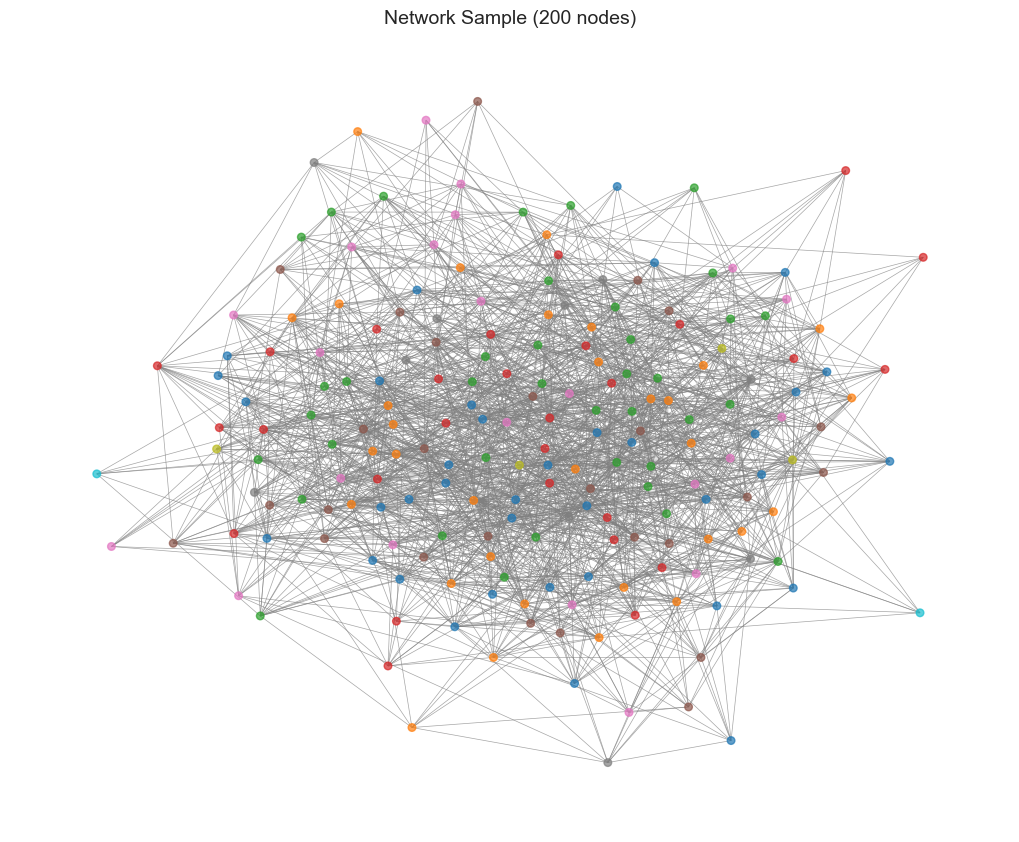

Network visualization saved to ../figures/network_sample.png

2. Testing OMC Computation...
   Computation time: 0.03s
   Local edges: 10648
   Global edges: 1052
   Communities: 10
   Overlapping nodes: 500 (100.0%)


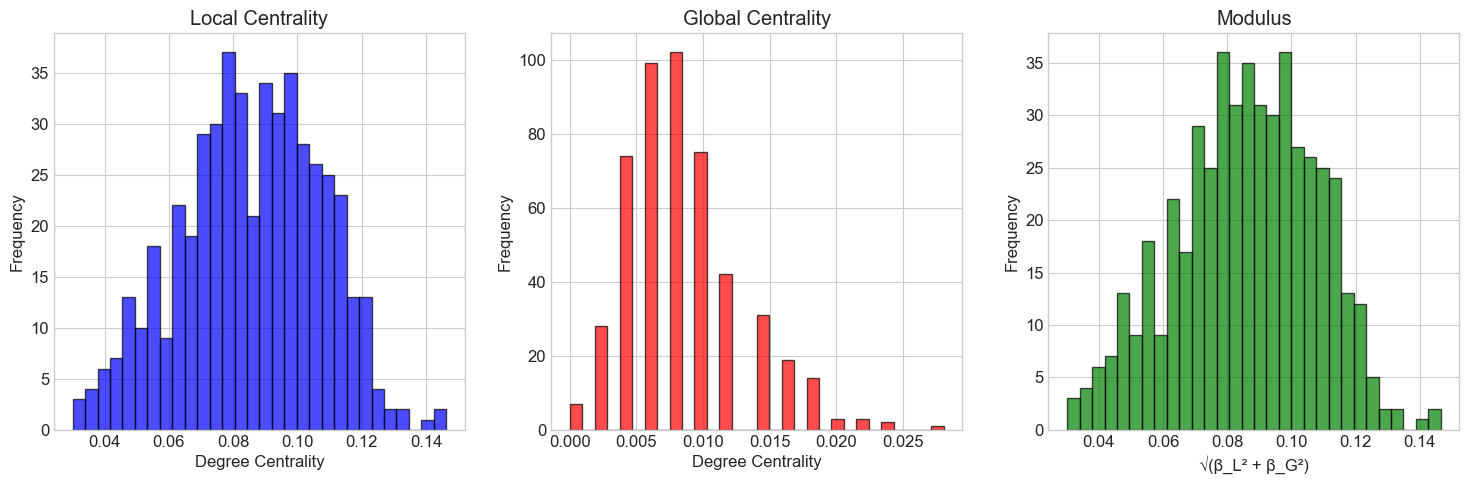

Centrality distributions saved.

3. Testing SIR Simulation...
   Epidemic threshold λ_th = 0.0205
   Using λ = 0.1, γ = 0.1
   Simulation time: 0.20s
   Outbreak size: 500.0 ± 0.0

ALL COMPONENTS TESTED SUCCESSFULLY!


In [6]:
print("="*60)
print("OMC REPLICATION STUDY - COMPONENT TESTING")
print("="*60)

# Test LFR generation
print("\n1. Testing LFR Network Generator...")
start_time = time.time()
G_test, comms_test, overlap_test = generate_lfr_benchmark(N=500, mu=0.1, seed=42)
gen_time = time.time() - start_time
print(f"   Generated: {G_test.number_of_nodes()} nodes, {G_test.number_of_edges()} edges")
print(f"   Generation time: {gen_time:.2f}s")

actual_mu = compute_mixing_parameter(G_test, comms_test)
on_pct, avg_om, n_overlap = compute_overlapping_stats(comms_test, 500)
print(f"   Actual μ: {actual_mu:.3f}")
print(f"   Overlapping: {n_overlap} nodes ({on_pct:.1f}%)")

# Visualize
visualize_network_sample(G_test, comms_test, n_sample=200)

# Test OMC computation
print("\n2. Testing OMC Computation...")
start_time = time.time()
omc_test = OverlappingModularCentrality(G_test, comms_test)
omc_time = time.time() - start_time
stats = omc_test.get_stats()
print(f"   Computation time: {omc_time:.2f}s")
print(f"   Local edges: {stats['n_local_edges']}")
print(f"   Global edges: {stats['n_global_edges']}")
print(f"   Communities: {stats['n_communities']}")
print(f"   Overlapping nodes: {stats['n_overlapping']} ({stats['overlapping_percent']:.1f}%)")

# Plot centrality distributions
omc_test.plot_centrality_distribution('degree')

# Test SIR simulation
print("\n3. Testing SIR Simulation...")
lambda_rate = 0.1
gamma = 0.1
lambda_th = compute_epidemic_threshold(G_test)
print(f"   Epidemic threshold λ_th = {lambda_th:.4f}")
print(f"   Using λ = {lambda_rate}, γ = {gamma}")

start_time = time.time()
sim_test = SIRSimulator(G_test, lambda_rate, gamma)
seeds = set(random.sample(list(G_test.nodes()), 5))
R_avg, R_std = sim_test.run_multiple(seeds, n_runs=10)
sim_time = time.time() - start_time
print(f"   Simulation time: {sim_time:.2f}s")
print(f"   Outbreak size: {R_avg:.1f} ± {R_std:.1f}")

print("\n" + "="*60)
print("ALL COMPONENTS TESTED SUCCESSFULLY!")
print("="*60)

## 6. Figure 3: Community Strength

This experiment replicates **Figure 3** from the paper, showing how community structure strength affects OMC performance.

### Experimental Setup:
- **μ values**: 0.1 (strong), 0.4 (medium), 0.6 (weak)
- **f₀ values**: 2%, 6%, 10%, 14% (initial spreaders)
- **Measures**: Degree centrality (local, global, modulus, weighted)
- **SIR parameters**: λ=0.1, γ=0.1

Running Figure 3 experiment...

Generating LFR network with μ=0.1...
  Actual μ = 0.123
  Computing local...
  Computing global...
  Computing modulus...
  Computing weighted...

Generating LFR network with μ=0.4...
  Actual μ = 0.414
  Computing local...
  Computing global...
  Computing modulus...
  Computing weighted...

Generating LFR network with μ=0.6...
  Actual μ = 0.594
  Computing local...
  Computing global...
  Computing modulus...
  Computing weighted...


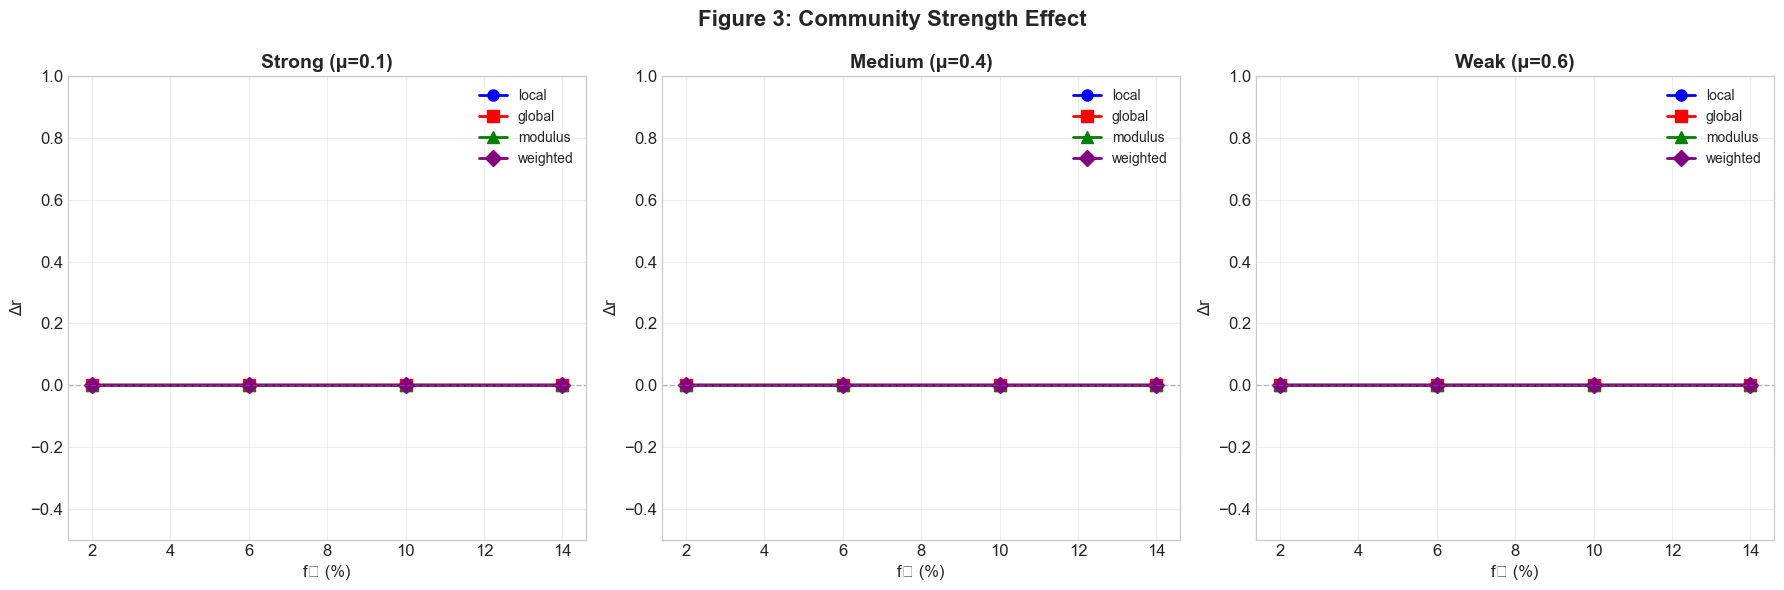


Figure 3 saved to ../figures/figure3_community_strength.png

FIGURE 3 SUMMARY

μ = 0.1:
  local     : Δr = 0.0000
  global    : Δr = 0.0000
  modulus   : Δr = 0.0000
  weighted  : Δr = 0.0000

μ = 0.4:
  local     : Δr = 0.0000
  global    : Δr = -0.0001
  modulus   : Δr = 0.0000
  weighted  : Δr = 0.0000

μ = 0.6:
  local     : Δr = 0.0001
  global    : Δr = 0.0000
  modulus   : Δr = 0.0000
  weighted  : Δr = 0.0001


In [7]:
def run_figure3(N=1000, n_runs=10):
    """Run Figure 3 experiment."""
    mu_values = [0.1, 0.4, 0.6]
    f0_values = np.linspace(0.02, 0.14, 4)
    methods = ['local', 'global', 'modulus', 'weighted']
    results = {}
    
    for mu in mu_values:
        print(f"\nGenerating LFR network with μ={mu}...")
        G, communities, _ = generate_lfr_benchmark(N=N, mu=mu, on=int(N*0.1), seed=42)
        actual_mu = compute_mixing_parameter(G, communities)
        print(f"  Actual μ = {actual_mu:.3f}")
        
        omc = OverlappingModularCentrality(G, communities)
        standard = dict(nx.degree_centrality(G))
        results[mu] = {'actual_mu': actual_mu, 'methods': {}}
        
        local = omc.compute_local_centrality('degree')
        global_ = omc.compute_global_centrality('degree')
        modulus = omc.compute_modulus('degree')
        weighted = omc.compute_weighted_omc('degree')
        
        for method_name, scores in [('local', local), ('global', global_), 
                                      ('modulus', modulus), ('weighted', weighted)]:
            print(f"  Computing {method_name}...")
            delta_r_values = []
            for f0 in f0_values:
                delta_r = compute_delta_r(G, scores, standard, f0, n_runs=n_runs)
                delta_r_values.append(delta_r)
            results[mu]['methods'][method_name] = {'f0': f0_values, 'delta_r': delta_r_values}
    
    return results

def plot_figure3(results):
    """Plot Figure 3 results."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    mu_values = [0.1, 0.4, 0.6]
    mu_labels = ['Strong (μ=0.1)', 'Medium (μ=0.4)', 'Weak (μ=0.6)']
    methods = ['local', 'global', 'modulus', 'weighted']
    colors = ['blue', 'red', 'green', 'purple']
    markers = ['o', 's', '^', 'D']
    
    for idx, mu in enumerate(mu_values):
        ax = axes[idx]
        for method, color, marker in zip(methods, colors, markers):
            data = results[mu]['methods'][method]
            ax.plot(data['f0']*100, data['delta_r'], 
                   marker=marker, markersize=8, linewidth=2, 
                   color=color, label=method)
        
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.set_xlabel('f₀ (%)', fontsize=12)
        ax.set_ylabel('Δr', fontsize=12)
        ax.set_title(mu_labels[idx], fontsize=14, fontweight='bold')
        ax.legend(fontsize=10, loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.5, 1.0)
    
    plt.suptitle('Figure 3: Community Strength Effect', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figures/figure3_community_strength.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nFigure 3 saved to ../figures/figure3_community_strength.png")

# Run and plot
print("Running Figure 3 experiment...")
fig3_results = run_figure3(N=1000, n_runs=10)
plot_figure3(fig3_results)

# Print summary
print("\n" + "="*60)
print("FIGURE 3 SUMMARY")
print("="*60)
for mu in [0.1, 0.4, 0.6]:
    print(f"\nμ = {mu}:")
    for method in ['local', 'global', 'modulus', 'weighted']:
        delta_r = fig3_results[mu]['methods'][method]['delta_r'][-1]  # Last f0 value
        print(f"  {method:10s}: Δr = {delta_r:.4f}")

## 7. Figures 4-6: Overlapping Nodes

These experiments show how the percentage of overlapping nodes (oₙ) affects performance.

- **Figure 4**: Local vs Standard
- **Figure 5**: Global vs Standard
- **Figure 6**: Modulus vs Standard

Running Figures 4-6 experiments...

μ=0.1, on=10%...

μ=0.1, on=30%...

μ=0.1, on=50%...

μ=0.4, on=10%...

μ=0.4, on=30%...

μ=0.4, on=50%...

μ=0.6, on=10%...

μ=0.6, on=30%...

μ=0.6, on=50%...


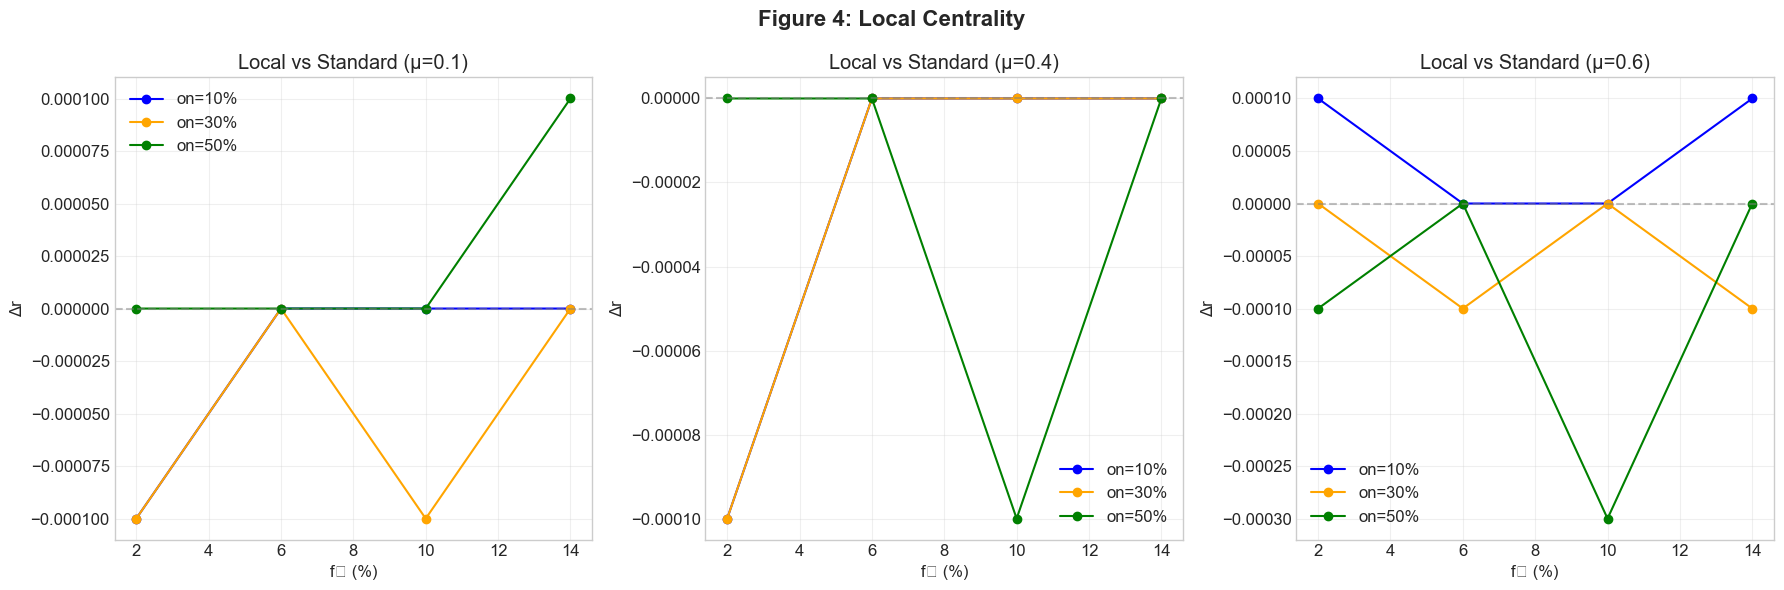

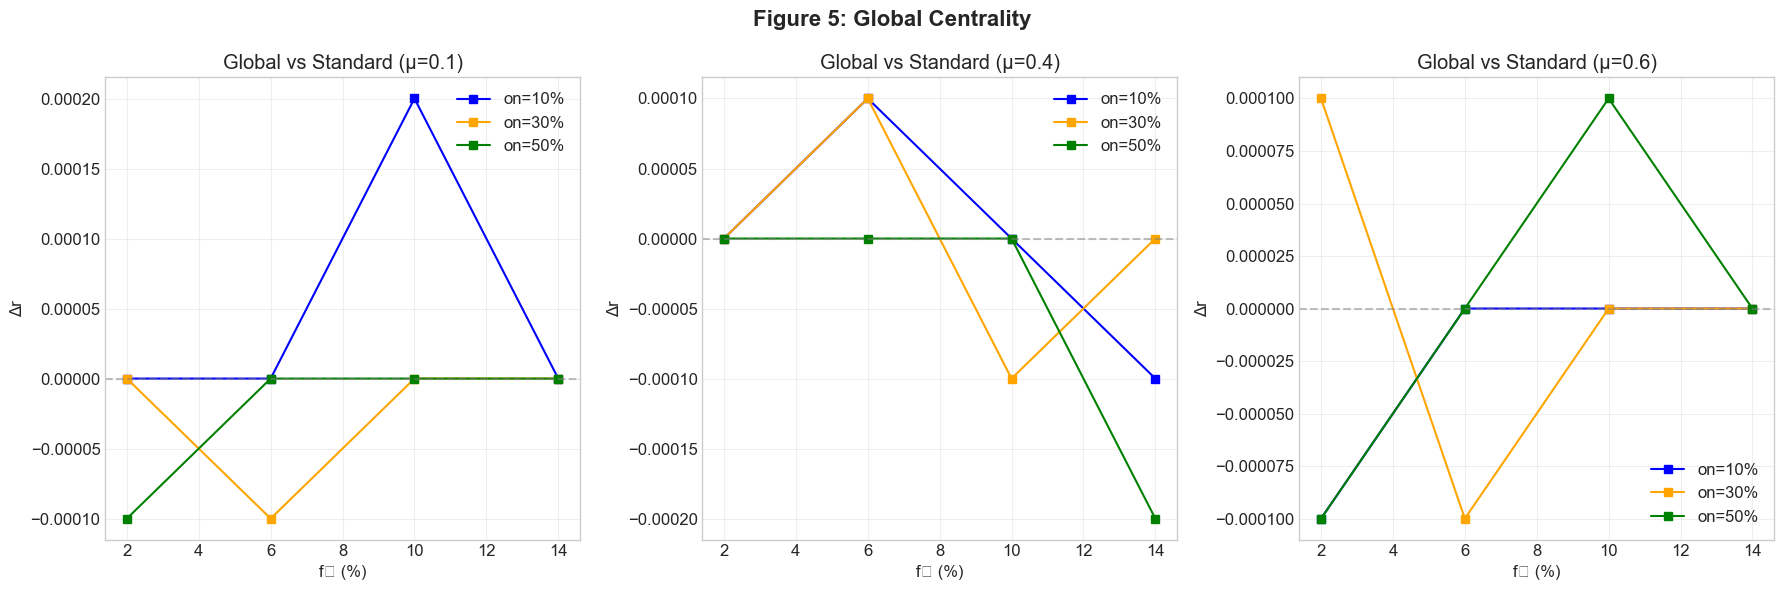

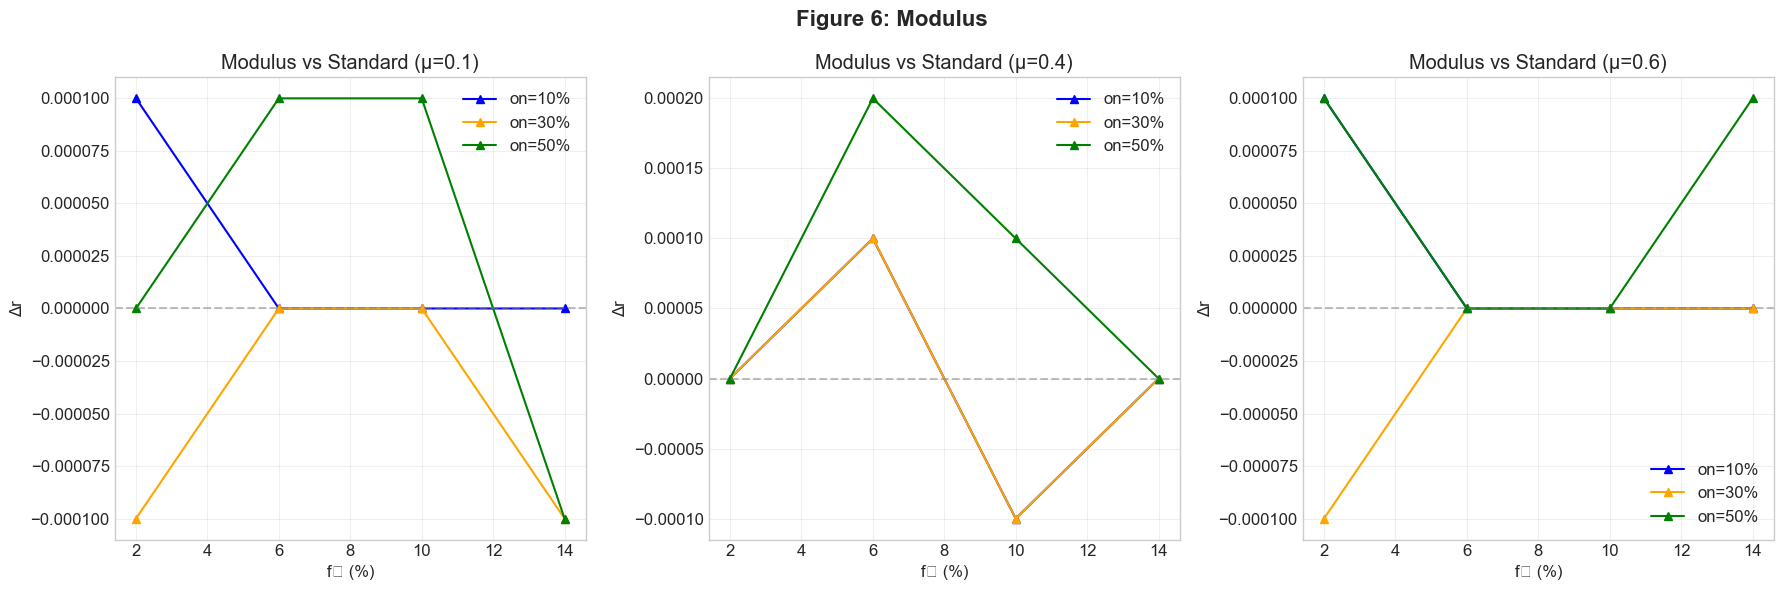


Figures 4-6 saved to ../figures/


In [8]:
def run_figures456(N=1000, n_runs=10):
    """Run Figures 4-6 experiments."""
    mu_values = [0.1, 0.4, 0.6]
    on_percentages = [10, 30, 50]
    f0_values = np.linspace(0.02, 0.14, 4)
    results = {}
    
    for mu in mu_values:
        results[mu] = {}
        for on_pct in on_percentages:
            print(f"\nμ={mu}, on={on_pct}%...")
            G, communities, _ = generate_lfr_benchmark(N=N, mu=mu, on=int(N*on_pct/100), seed=42)
            omc = OverlappingModularCentrality(G, communities)
            standard = dict(nx.degree_centrality(G))
            
            local = omc.compute_local_centrality('degree')
            global_ = omc.compute_global_centrality('degree')
            modulus = omc.compute_modulus('degree')
            
            results[mu][on_pct] = {
                'local': [compute_delta_r(G, local, standard, f0, n_runs=n_runs) for f0 in f0_values],
                'global': [compute_delta_r(G, global_, standard, f0, n_runs=n_runs) for f0 in f0_values],
                'modulus': [compute_delta_r(G, modulus, standard, f0, n_runs=n_runs) for f0 in f0_values],
                'f0': f0_values
            }
    
    return results

def plot_figures456(results):
    """Plot Figures 4, 5, 6."""
    mu_values = [0.1, 0.4, 0.6]
    on_percentages = [10, 30, 50]
    colors = ['blue', 'orange', 'green']
    
    # Figure 4: Local
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for idx, mu in enumerate(mu_values):
        ax = axes[idx]
        for on_idx, on_pct in enumerate(on_percentages):
            data = results[mu][on_pct]['local']
            ax.plot(results[mu][on_pct]['f0']*100, data, 
                   marker='o', label=f'on={on_pct}%', color=colors[on_idx])
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('f₀ (%)')
        ax.set_ylabel('Δr')
        ax.set_title(f'Local vs Standard (μ={mu})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle('Figure 4: Local Centrality', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figures/figure4_local.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Figure 5: Global
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for idx, mu in enumerate(mu_values):
        ax = axes[idx]
        for on_idx, on_pct in enumerate(on_percentages):
            data = results[mu][on_pct]['global']
            ax.plot(results[mu][on_pct]['f0']*100, data, 
                   marker='s', label=f'on={on_pct}%', color=colors[on_idx])
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('f₀ (%)')
        ax.set_ylabel('Δr')
        ax.set_title(f'Global vs Standard (μ={mu})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle('Figure 5: Global Centrality', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figures/figure5_global.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Figure 6: Modulus
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for idx, mu in enumerate(mu_values):
        ax = axes[idx]
        for on_idx, on_pct in enumerate(on_percentages):
            data = results[mu][on_pct]['modulus']
            ax.plot(results[mu][on_pct]['f0']*100, data, 
                   marker='^', label=f'on={on_pct}%', color=colors[on_idx])
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('f₀ (%)')
        ax.set_ylabel('Δr')
        ax.set_title(f'Modulus vs Standard (μ={mu})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle('Figure 6: Modulus', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figures/figure6_modulus.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nFigures 4-6 saved to ../figures/")

# Run and plot
print("Running Figures 4-6 experiments...")
fig456_results = run_figures456(N=1000, n_runs=10)
plot_figures456(fig456_results)

## 8. Real-World Network Analysis

Analysis of real-world networks from the paper:
- **ego-Facebook**: Social network (strong community structure)
- **Caltech**: Facebook friendship network (medium community structure)
- **Netscience**: Co-authorship network (strong community structure)

Running real-world network analysis...
Loading ego-Facebook...
  ✓ 4039 nodes, 88234 edges
Loading Caltech...
  ✓ 762 nodes, 16651 edges
Loading Netscience...
  ✓ 379 nodes, 914 edges

Analyzing ego-Facebook...
Nodes: 4,039
Edges: 88,234
Epidemic threshold λ_th = 0.0095

Detecting communities with SLPA...
Community detection time: 62.19s

Communities: 11
Overlapping: 11 (0.3%)
Local edges: 87,269
Global edges: 965

Running SIR experiments...

Analyzing Caltech...
Nodes: 762
Edges: 16,651
Epidemic threshold λ_th = 0.0135

Detecting communities with SLPA...
Community detection time: 11.39s

Communities: 1
Overlapping: 0 (0.0%)
Local edges: 16,651
Global edges: 0

Running SIR experiments...

Analyzing Netscience...
Nodes: 379
Edges: 914
Epidemic threshold λ_th = 0.1424

Detecting communities with SLPA...
Community detection time: 0.70s

Communities: 31
Overlapping: 31 (8.2%)
Local edges: 837
Global edges: 77

Running SIR experiments...


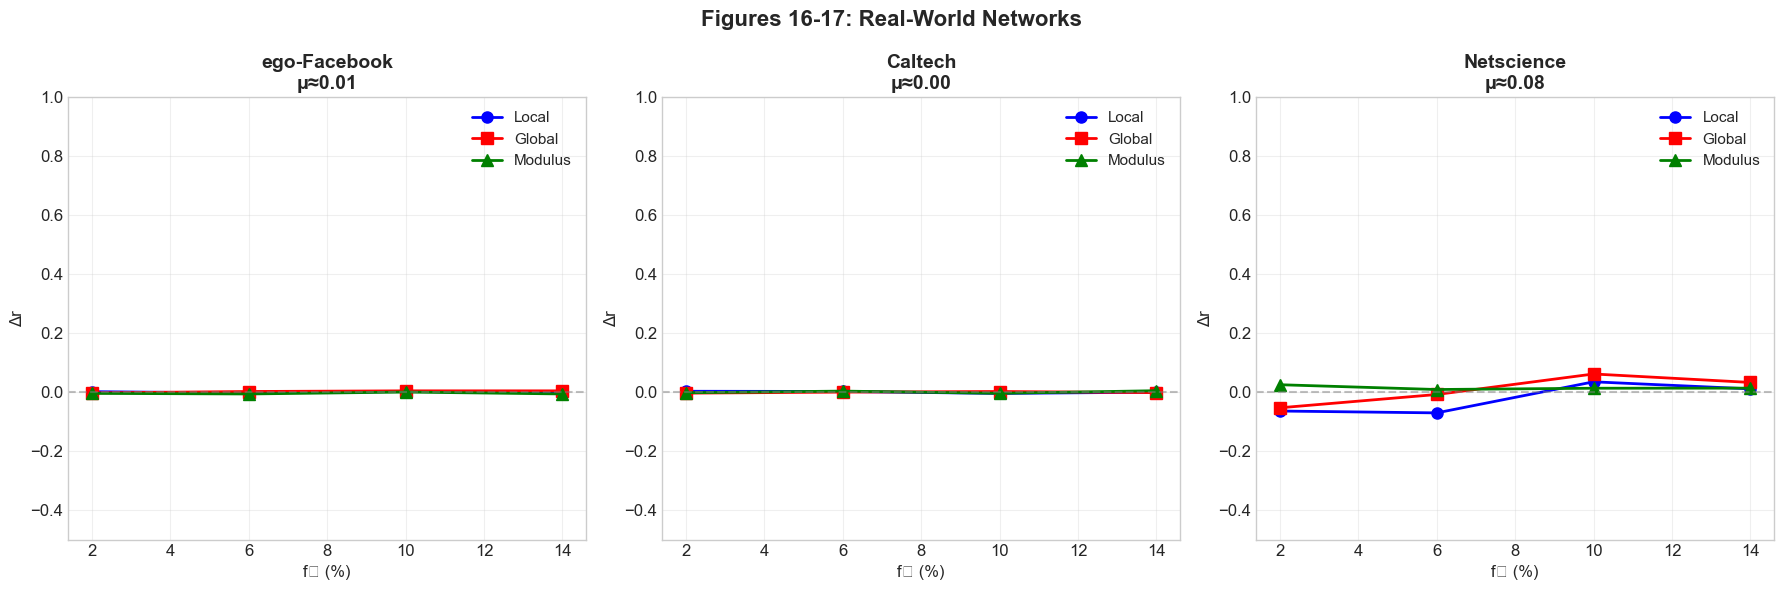


Real-world results saved to ../figures/figure16_17_realworld.png

REAL-WORLD NETWORK SUMMARY
Network            Nodes      Edges  Communities  Overlap %
----------------------------------------------------------------------
ego-Facebook       4,039     88,234           11       0.3%
Caltech              762     16,651            1       0.0%
Netscience           379        914           31       8.2%


In [9]:
def load_real_world_networks():
    """Load real-world networks."""
    networks = {}
    
    # ego-Facebook
    try:
        print("Loading ego-Facebook...")
        G_fb = nx.read_edgelist('../data/ego-facebook/facebook_combined.txt', nodetype=int)
        G_fb = G_fb.subgraph(max(nx.connected_components(G_fb), key=len)).copy()
        networks['ego-Facebook'] = G_fb
        print(f"  ✓ {G_fb.number_of_nodes()} nodes, {G_fb.number_of_edges()} edges")
    except FileNotFoundError:
        print("  ✗ ego-Facebook not found")
    
    # Caltech
    try:
        print("Loading Caltech...")
        import scipy.io as sio
        mat = sio.mmread('../data/caltech/socfb-Caltech36.mtx')
        mat = mat.tocoo()
        G_cal = nx.Graph()
        for u, v in zip(mat.row, mat.col):
            if u != v:
                G_cal.add_edge(int(u), int(v))
        G_cal = G_cal.subgraph(max(nx.connected_components(G_cal), key=len)).copy()
        networks['Caltech'] = G_cal
        print(f"  ✓ {G_cal.number_of_nodes()} nodes, {G_cal.number_of_edges()} edges")
    except FileNotFoundError:
        print("  ✗ Caltech not found")
    
    # Netscience
    try:
        print("Loading Netscience...")
        df = pd.read_csv('../data/netscience/edges.csv')
        G_ns = nx.Graph()
        for _, row in df.iterrows():
            u, v = int(row.iloc[0]), int(row.iloc[1])
            if u != v:
                G_ns.add_edge(u, v)
        G_ns = G_ns.subgraph(max(nx.connected_components(G_ns), key=len)).copy()
        networks['Netscience'] = G_ns
        print(f"  ✓ {G_ns.number_of_nodes()} nodes, {G_ns.number_of_edges()} edges")
    except FileNotFoundError:
        print("  ✗ Netscience not found")
    
    return networks

def analyze_real_world(n_runs=10):
    """Analyze real-world networks."""
    networks = load_real_world_networks()
    results = {}
    
    for name, G in networks.items():
        print(f"\n{'='*50}")
        print(f"Analyzing {name}...")
        print(f"{'='*50}")
        
        # Network stats
        lambda_th = compute_epidemic_threshold(G)
        print(f"Nodes: {G.number_of_nodes():,}")
        print(f"Edges: {G.number_of_edges():,}")
        print(f"Epidemic threshold λ_th = {lambda_th:.4f}")
        
        # Community detection
        print("\nDetecting communities with SLPA...")
        start = time.time()
        communities = algorithms.slpa(G, t=100, r=0.1).communities
        communities = [set(c) for c in communities]
        print(f"Community detection time: {time.time()-start:.2f}s")
        
        # OMC
        omc = OverlappingModularCentrality(G, communities)
        stats = omc.get_stats()
        print(f"\nCommunities: {stats['n_communities']}")
        print(f"Overlapping: {stats['n_overlapping']} ({stats['overlapping_percent']:.1f}%)")
        print(f"Local edges: {stats['n_local_edges']:,}")
        print(f"Global edges: {stats['n_global_edges']:,}")
        
        # Centralities
        standard = dict(nx.degree_centrality(G))
        local = omc.compute_local_centrality('degree')
        global_ = omc.compute_global_centrality('degree')
        modulus = omc.compute_modulus('degree')
        
        # SIR experiments
        print("\nRunning SIR experiments...")
        f0_values = np.linspace(0.02, 0.14, 4)
        delta_r_local = [compute_delta_r(G, local, standard, f0, n_runs=n_runs) for f0 in f0_values]
        delta_r_global = [compute_delta_r(G, global_, standard, f0, n_runs=n_runs) for f0 in f0_values]
        delta_r_modulus = [compute_delta_r(G, modulus, standard, f0, n_runs=n_runs) for f0 in f0_values]
        
        results[name] = {
            'stats': stats,
            'lambda_th': lambda_th,
            'f0': f0_values,
            'delta_r_local': delta_r_local,
            'delta_r_global': delta_r_global,
            'delta_r_modulus': delta_r_modulus
        }
    
    return results

def plot_real_world(results):
    """Plot real-world results (Figures 16-17)."""
    n_networks = len(results)
    fig, axes = plt.subplots(1, n_networks, figsize=(6*n_networks, 6))
    if n_networks == 1:
        axes = [axes]
    
    for idx, (name, data) in enumerate(results.items()):
        ax = axes[idx]
        
        ax.plot(data['f0']*100, data['delta_r_local'], 'bo-', label='Local', 
               marker='o', markersize=8, linewidth=2)
        ax.plot(data['f0']*100, data['delta_r_global'], 'ro-', label='Global', 
               marker='s', markersize=8, linewidth=2)
        ax.plot(data['f0']*100, data['delta_r_modulus'], 'go-', label='Modulus', 
               marker='^', markersize=8, linewidth=2)
        
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('f₀ (%)', fontsize=12)
        ax.set_ylabel('Δr', fontsize=12)
        ax.set_title(f'{name}\nμ≈{data["stats"]["n_global_edges"]/(data["stats"]["n_local_edges"]+data["stats"]["n_global_edges"]):.2f}', 
                    fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.5, 1.0)
    
    plt.suptitle('Figures 16-17: Real-World Networks', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figures/figure16_17_realworld.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nReal-world results saved to ../figures/figure16_17_realworld.png")

# Run analysis
print("Running real-world network analysis...")
real_world_results = analyze_real_world(n_runs=10)
plot_real_world(real_world_results)

# Summary table
print("\n" + "="*70)
print("REAL-WORLD NETWORK SUMMARY")
print("="*70)
print(f"{'Network':<15} {'Nodes':>8} {'Edges':>10} {'Communities':>12} {'Overlap %':>10}")
print("-"*70)
for name, data in real_world_results.items():
    stats = data['stats']
    print(f"{name:<15} {stats['n_nodes']:>8,} {stats['n_edges']:>10,} {stats['n_communities']:>12} {stats['overlapping_percent']:>9.1f}%")
print("="*70)